In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train_df = pd.read_csv(r"C:\Vinay Projects\6. AI-Demand-Forecasting\data\raw\train.csv")
test_df = pd.read_csv(r"C:\Vinay Projects\6. AI-Demand-Forecasting\data\raw\test.csv")

In [6]:
train_df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [7]:
test_df.head()

,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


In [8]:
print("Train Shape :", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape : (913000, 4)
Test Shape : (45000, 4)


In [9]:
train_df.columns

Index(['date', 'store', 'item', 'sales'], dtype='str')

In [11]:
test_df.columns

Index(['id', 'date', 'store', 'item'], dtype='str')

In [12]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB


In [13]:
train_df.dtypes

date       str
store    int64
item     int64
sales    int64
dtype: object

In [14]:
train_df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [15]:
train_df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [16]:
train_df.duplicated().sum()

np.int64(0)

In [17]:
train_df.duplicated().sum()

np.int64(0)

In [18]:
train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"] = pd.to_datetime(test_df["date"])

In [19]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[us]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 27.9 MB


In [20]:
print("Start Date :", train_df["date"].min())
print("End Date :", train_df["date"].max())

Start Date : 2013-01-01 00:00:00
End Date : 2017-12-31 00:00:00


In [21]:
train_df["store"].nunique()

10

In [22]:
train_df["sales"].describe()

count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64

In [23]:
train_df.nunique()

date     1826
store      10
item       50
sales     213
dtype: int64

In [24]:
train_df["year"] = train_df["date"].dt.year
train_df["month"] = train_df["date"].dt.month
train_df["day"] = train_df["date"].dt.day
train_df["day_of_week"] = train_df["date"].dt.dayofweek
train_df["week"] = train_df["date"].dt.isocalendar().week.astype(int)

In [25]:
train_df.head()

,date,store,item,sales,year,month,day,day_of_week,week
0,2013-01-01,1,1,13,2013,1,1,1,1
1,2013-01-02,1,1,11,2013,1,2,2,1
2,2013-01-03,1,1,14,2013,1,3,3,1
3,2013-01-04,1,1,13,2013,1,4,4,1
4,2013-01-05,1,1,10,2013,1,5,5,1


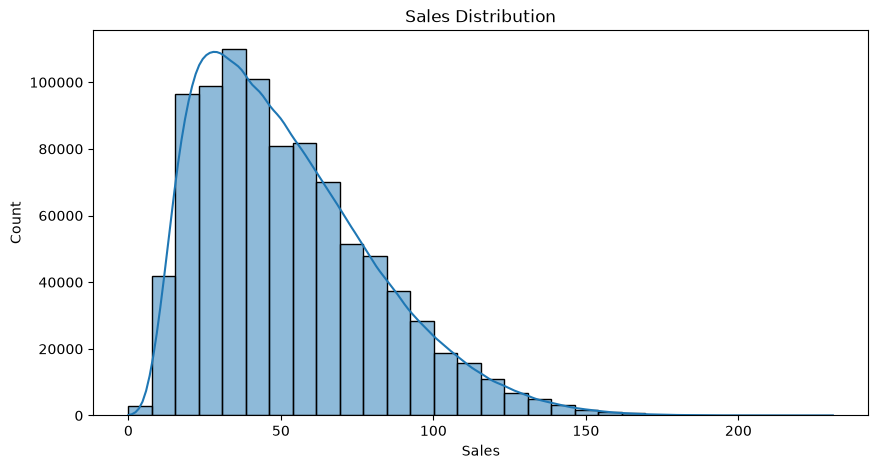

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(train_df["sales"], bins=30, kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Count")

plt.show()

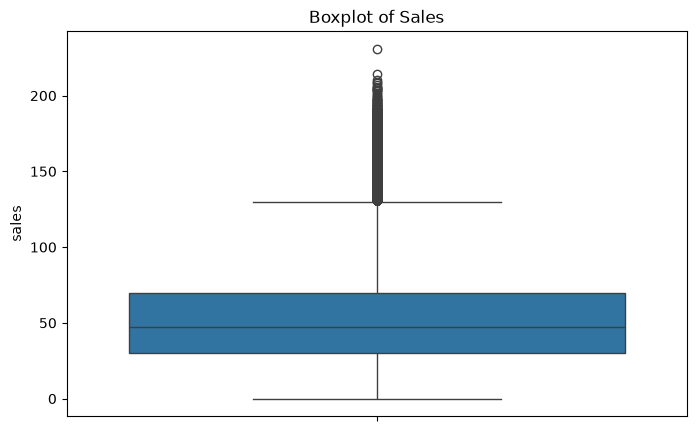

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(y=train_df["sales"])

plt.title("Boxplot of Sales")

plt.show()

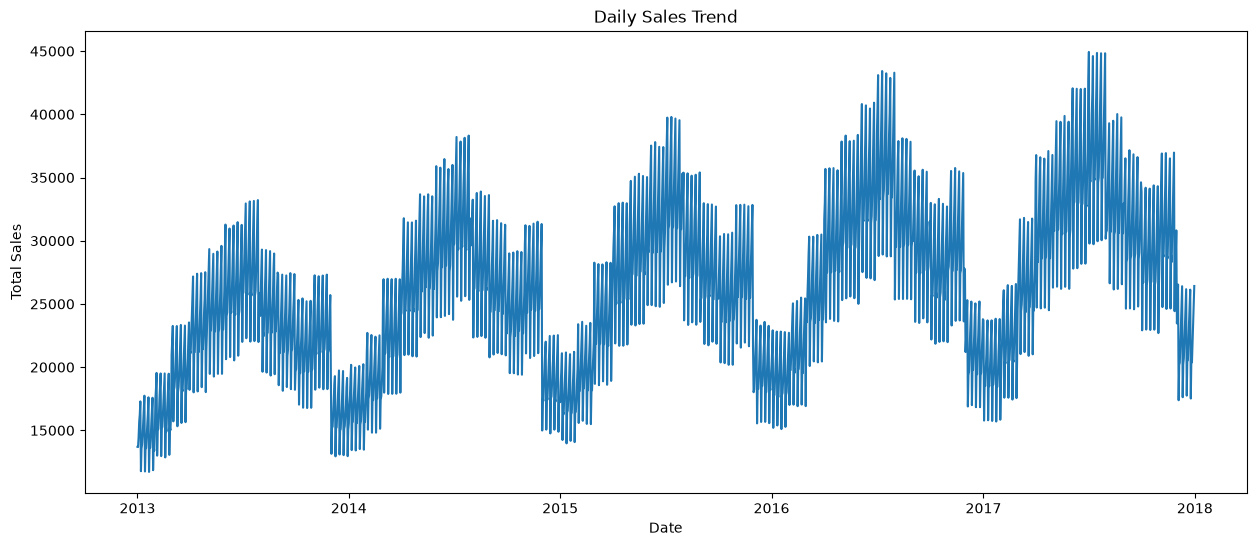

In [28]:
daily_sales = train_df.groupby("date")["sales"].sum()

plt.figure(figsize=(15,6))

plt.plot(daily_sales)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

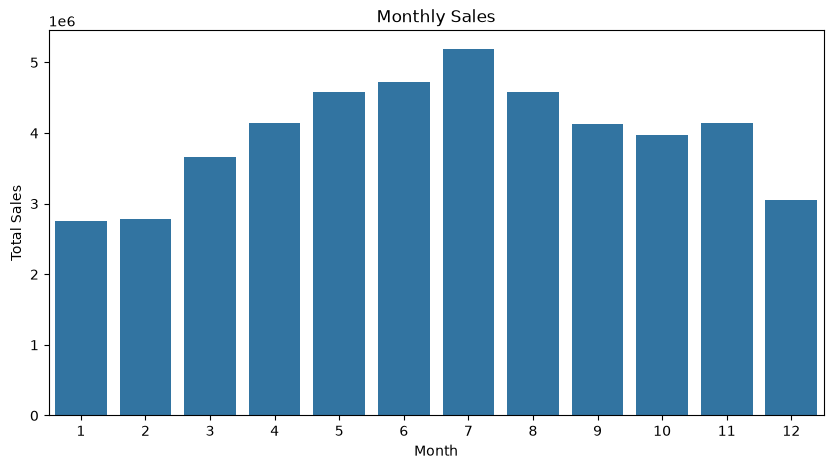

In [29]:
monthly_sales = train_df.groupby("month")["sales"].sum()

plt.figure(figsize=(10,5))

sns.barplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

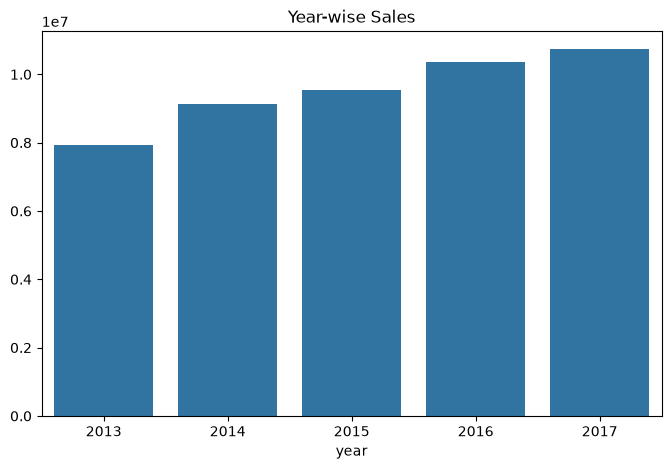

In [30]:
yearly_sales = train_df.groupby("year")["sales"].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=yearly_sales.index,
    y=yearly_sales.values
)

plt.title("Year-wise Sales")

plt.show()

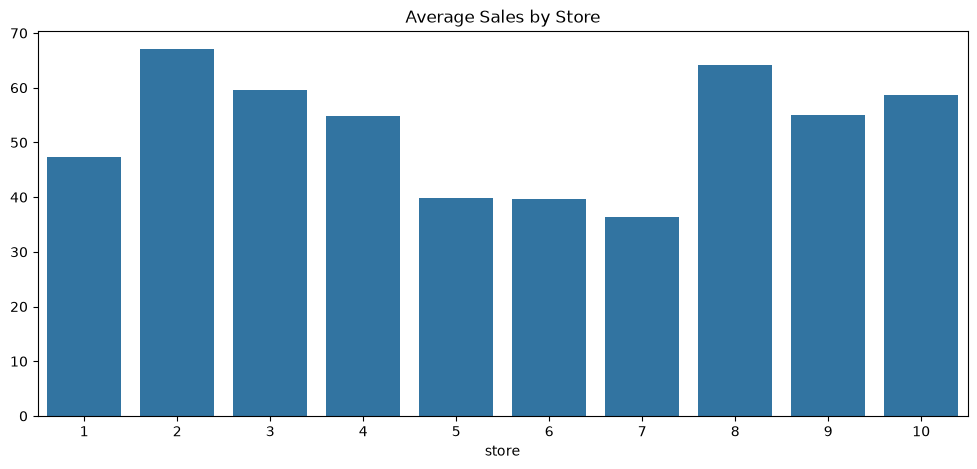

In [31]:
store_sales = train_df.groupby("store")["sales"].mean()

plt.figure(figsize=(12,5))

sns.barplot(
    x=store_sales.index,
    y=store_sales.values
)

plt.title("Average Sales by Store")

plt.show()

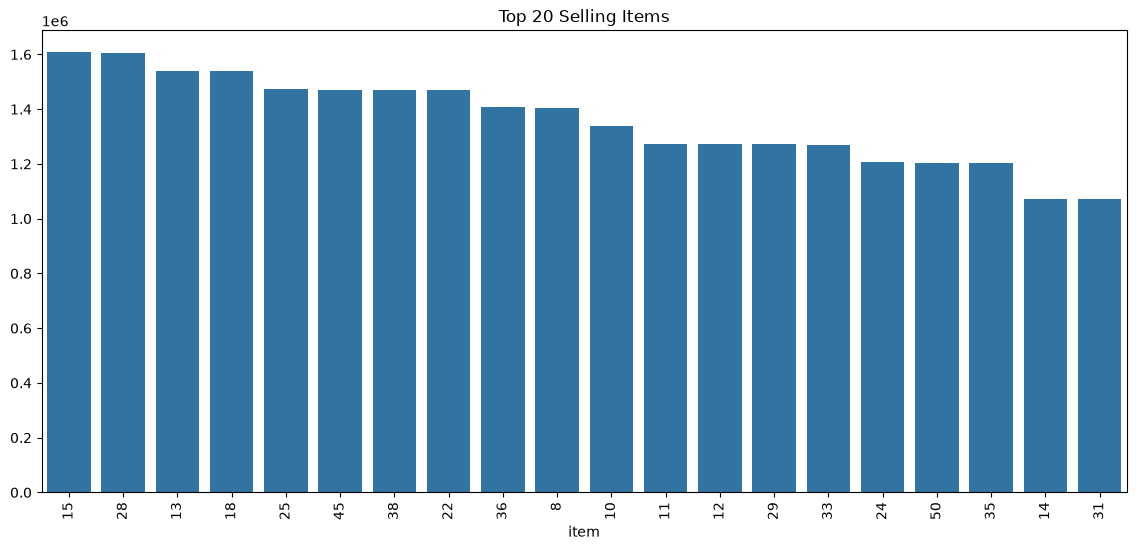

In [32]:
item_sales = train_df.groupby("item")["sales"].sum()

top_items = item_sales.sort_values(ascending=False).head(20)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_items.index.astype(str),
    y=top_items.values
)

plt.xticks(rotation=90)

plt.title("Top 20 Selling Items")

plt.show()

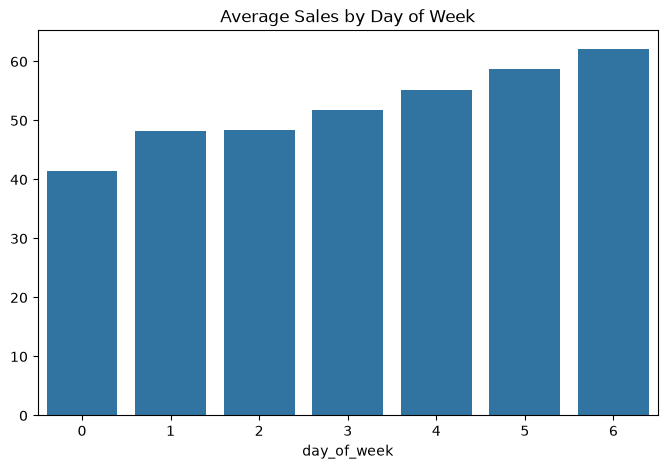

In [33]:
day_sales = train_df.groupby("day_of_week")["sales"].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=day_sales.index,
    y=day_sales.values
)

plt.title("Average Sales by Day of Week")

plt.show()

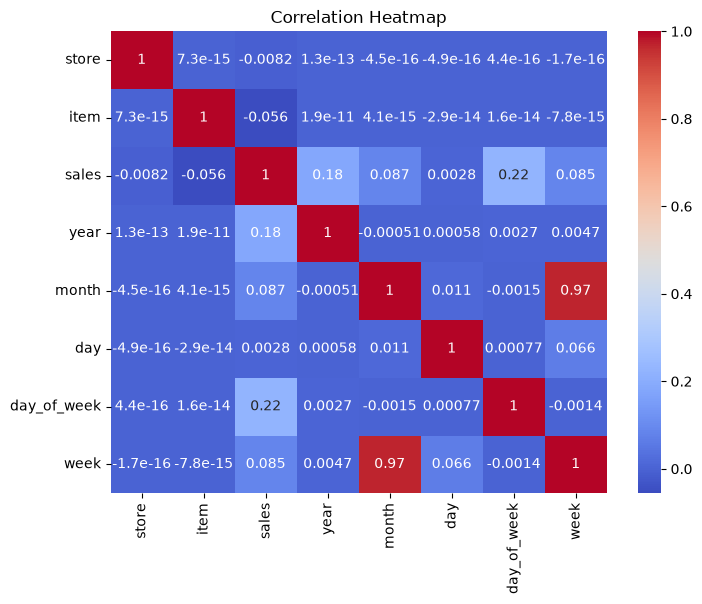

In [34]:
plt.figure(figsize=(8,6))

sns.heatmap(
    train_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [35]:
train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"] = pd.to_datetime(test_df["date"])

In [36]:
train_df = train_df.sort_values("date").reset_index(drop=True)

In [37]:
import os

# Create processed folder if it doesn't exist
os.makedirs("../data/processed", exist_ok=True)

# Save cleaned dataset
train_df.to_csv("../data/processed/clean_train.csv", index=False)
test_df.to_csv("../data/processed/clean_test.csv", index=False)

print("Processed datasets saved successfully!")

Processed datasets saved successfully!
